Data Summary:
Total stations: 426

Crime statistics:
count     426.000000
mean      760.964789
std       737.741043
min        15.000000
25%       226.500000
50%       544.500000
75%      1062.000000
max      5255.000000
Name: total_crimes, dtype: float64

Ridership statistics:
count     426.000000
mean      163.725188
std       236.116340
min         4.740000
25%        52.630000
50%        89.675000
75%       177.287500
max      2615.540000
Name: avg_hourly_riders, dtype: float64

Stations by borough:
borough
Bk    156
M     121
Q      79
Bx     68
SI      2
Name: count, dtype: int64


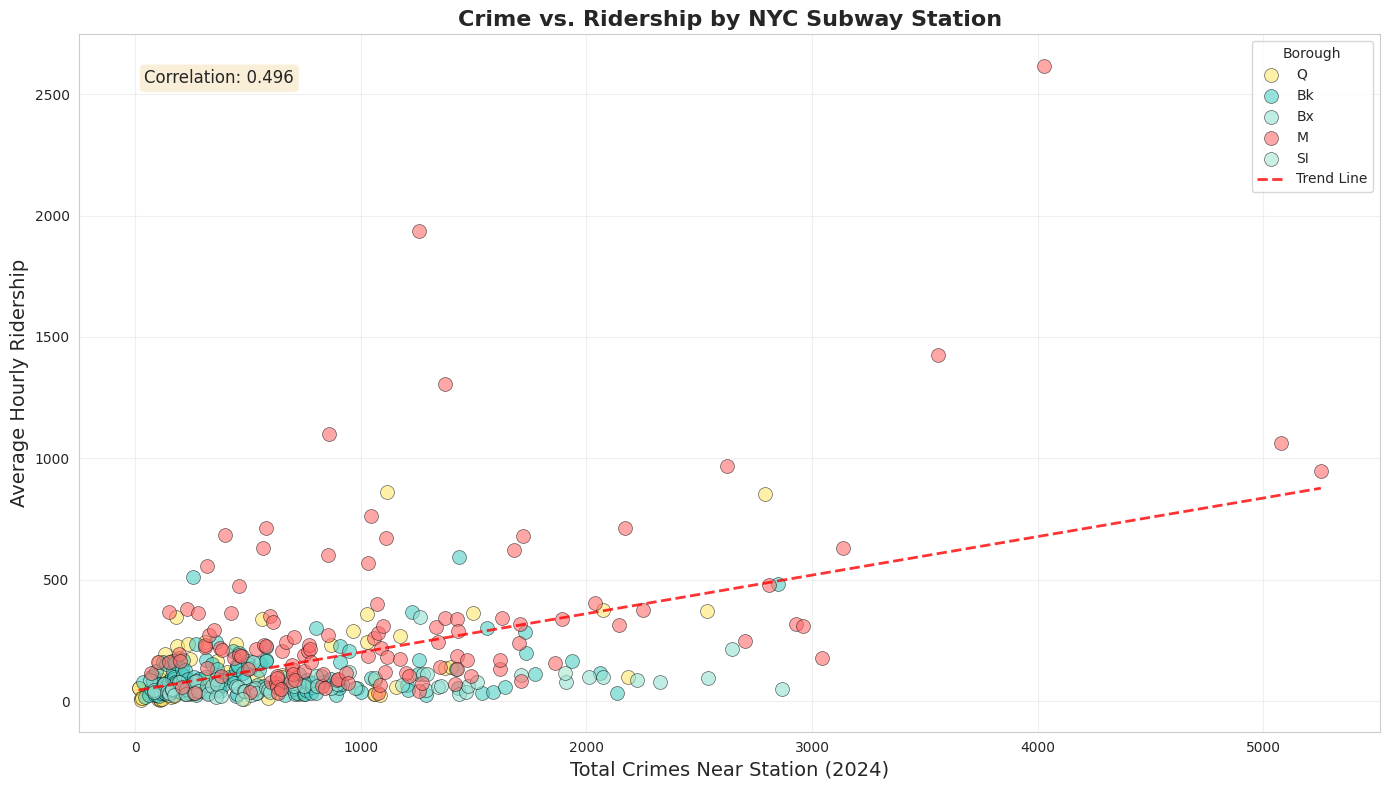

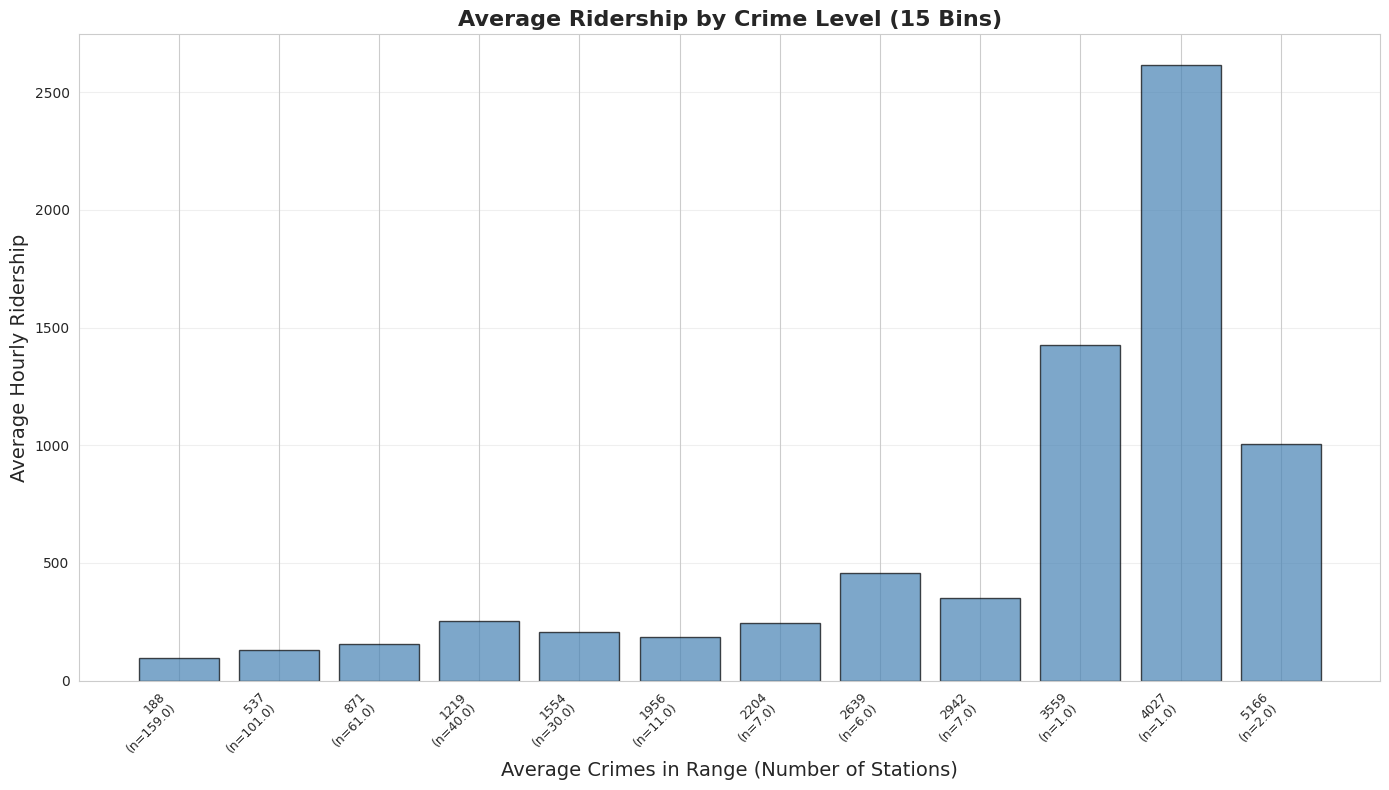

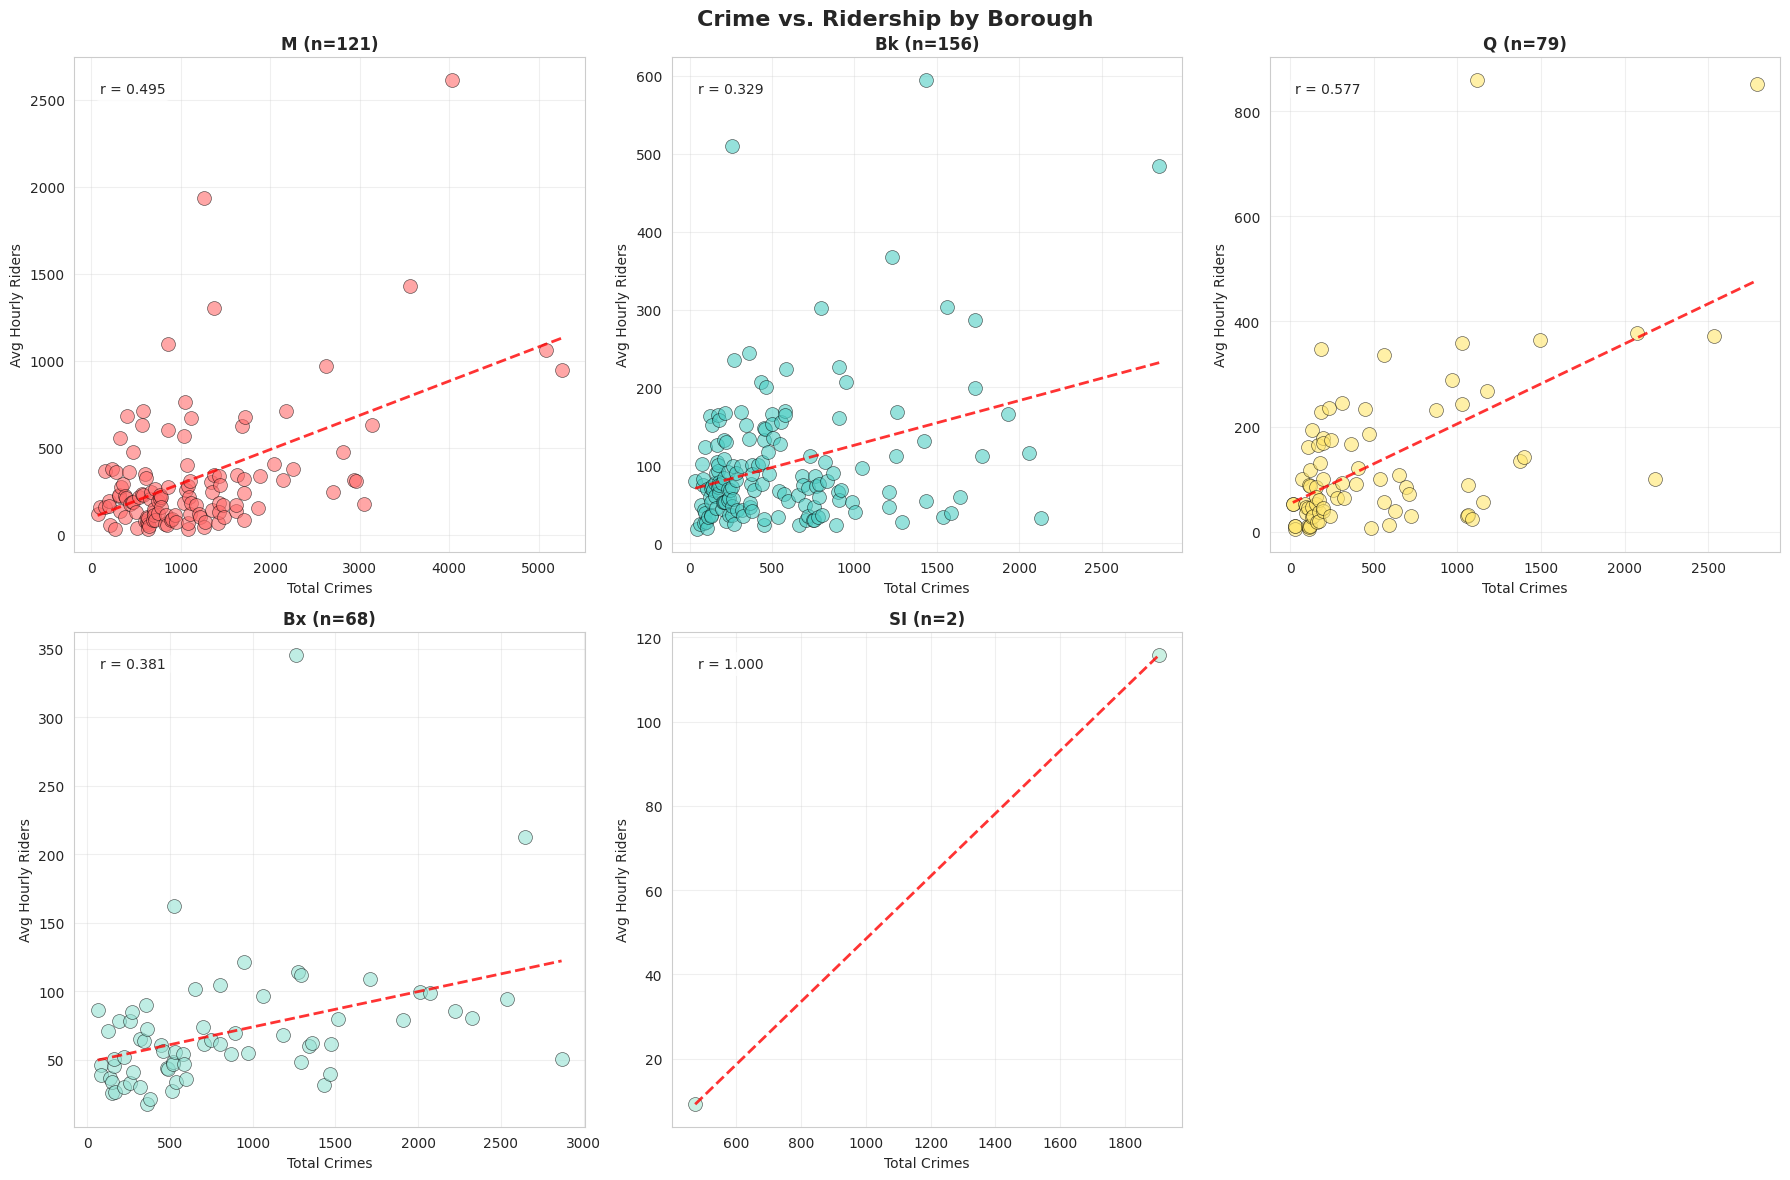

/tmp/ipython-input-2196494485.py:165: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='crime_quartile', y='avg_hourly_riders',


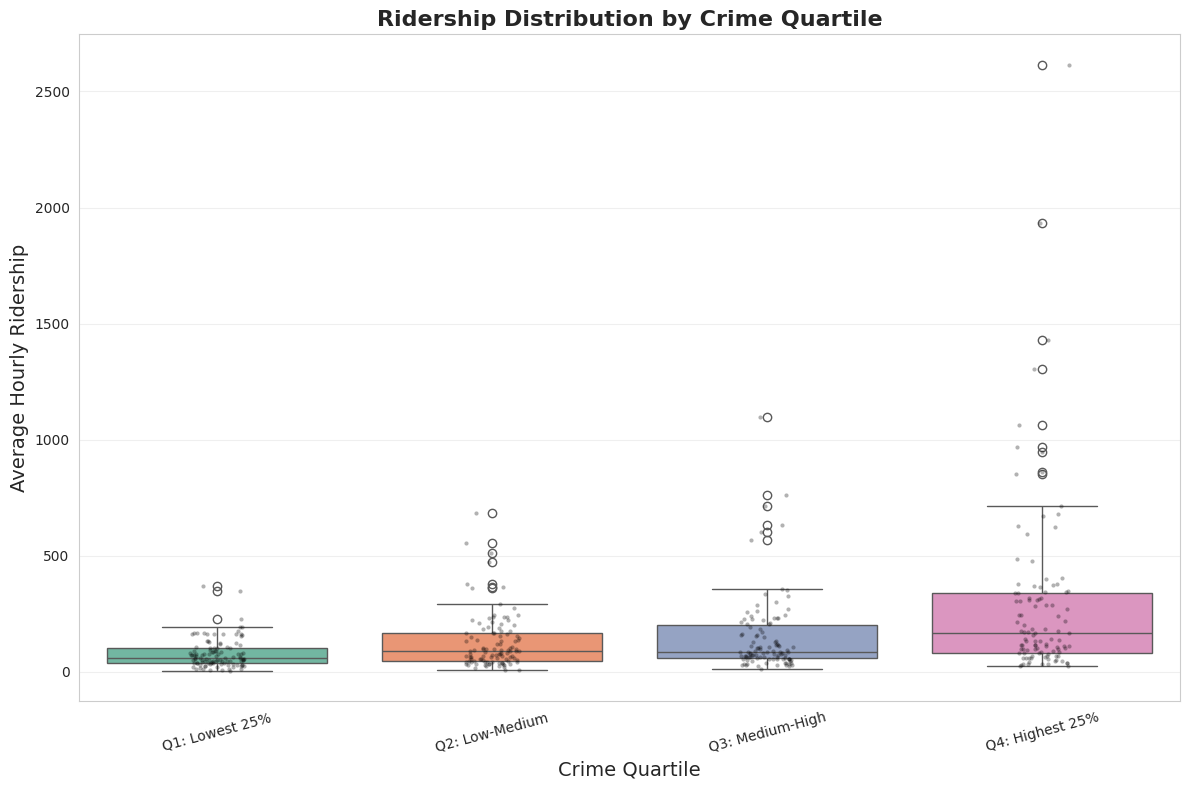


STATISTICAL ANALYSIS

Overall Correlation: 0.4960
P-value: 7.8592e-28
Relationship: Significant

Correlation by Borough:
  Q: r=0.5766, p=0.0000, n=79
  Bk: r=0.3285, p=0.0000, n=156
  Bx: r=0.3814, p=0.0013, n=68
  M: r=0.4953, p=0.0000, n=121

Top 10 Highest Crime Stations:
                                 stop_name borough  total_crimes  avg_hourly_riders
                        34 St-Penn Station       M          5255             948.26
                        34 St-Penn Station       M          5078            1063.90
Times Sq-42 St/Port Authority Bus Terminal       M          4027            2615.54
                           34 St-Herald Sq       M          3559            1427.57
                                  Canal St       M          3136             629.29
                                     28 St       M          3044             176.59
                                     50 St       M          2961             309.44
                                     50 St       M

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Load data
df = pd.read_csv('crime_ridership_data.csv')

print("Data Summary:")
print(f"Total stations: {len(df)}")
print(f"\nCrime statistics:")
print(df['total_crimes'].describe())
print(f"\nRidership statistics:")
print(df['avg_hourly_riders'].describe())
print(f"\nStations by borough:")
print(df['borough'].value_counts())


# Plot 1: Main Scatter Plot with Trend Line

plt.figure(figsize=(14, 8))


borough_colors = {
    'M': '#FF6B6B',    # Manhattan - Red
    'Bk': '#4ECDC4',   # Brooklyn - Teal
    'Q': '#FFE66D',    # Queens - Yellow
    'Bx': '#95E1D3',   # Bronx - Mint
    'SI': '#A8E6CF'    # Staten Island - Light Green
}


for borough in df['borough'].unique():
    borough_data = df[df['borough'] == borough]
    plt.scatter(borough_data['total_crimes'],
                borough_data['avg_hourly_riders'],
                c=borough_colors.get(borough, 'gray'),
                label=borough,
                alpha=0.6,
                s=100,
                edgecolors='black',
                linewidth=0.5)

# trend line
z = np.polyfit(df['total_crimes'], df['avg_hourly_riders'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['total_crimes'].min(), df['total_crimes'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend Line')

# correlation
correlation = df['total_crimes'].corr(df['avg_hourly_riders'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('Total Crimes Near Station (2024)', fontsize=14)
plt.ylabel('Average Hourly Ridership', fontsize=14)
plt.title('Crime vs. Ridership by NYC Subway Station', fontsize=16, fontweight='bold')
plt.legend(title='Borough', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('crime_vs_ridership_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


# Plot 2: Binned Bar Chart (More Uniform)

plt.figure(figsize=(14, 8))

# 15 equal-width bins
df['crime_bin'] = pd.cut(df['total_crimes'], bins=15)
binned = df.groupby('crime_bin', observed=True).agg({
    'avg_hourly_riders': 'mean',
    'total_crimes': 'mean',
    'complex_id': 'count'
}).rename(columns={'complex_id': 'num_stations'})

# labels showing crime range and station count
labels = [f"{int(row['total_crimes'])}\n(n={row['num_stations']})"
          for _, row in binned.iterrows()]

x_pos = np.arange(len(binned))
plt.bar(x_pos, binned['avg_hourly_riders'],
        color='steelblue', alpha=0.7, edgecolor='black')

plt.xlabel('Average Crimes in Range (Number of Stations)', fontsize=14)
plt.ylabel('Average Hourly Ridership', fontsize=14)
plt.title('Average Ridership by Crime Level (15 Bins)', fontsize=16, fontweight='bold')
plt.xticks(x_pos, labels, rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ridership_by_crime_bins.png', dpi=300, bbox_inches='tight')
plt.show()


# Plot 3: Crime Distribution by Borough

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Crime vs. Ridership by Borough', fontsize=16, fontweight='bold')

boroughs = ['M', 'Bk', 'Q', 'Bx', 'SI']
for idx, borough in enumerate(boroughs):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    borough_data = df[df['borough'] == borough]

    if len(borough_data) > 0:
        # Scatter plot
        ax.scatter(borough_data['total_crimes'],
                   borough_data['avg_hourly_riders'],
                   c=borough_colors.get(borough, 'gray'),
                   alpha=0.6,
                   s=100,
                   edgecolors='black',
                   linewidth=0.5)

        # Trend line
        if len(borough_data) > 1:
            z = np.polyfit(borough_data['total_crimes'],
                          borough_data['avg_hourly_riders'], 1)
            p = np.poly1d(z)
            x_trend = np.linspace(borough_data['total_crimes'].min(),
                                 borough_data['total_crimes'].max(), 50)
            ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)

            # Correlation
            corr = borough_data['total_crimes'].corr(borough_data['avg_hourly_riders'])
            ax.text(0.05, 0.95, f'r = {corr:.3f}',
                   transform=ax.transAxes,
                   fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_title(f'{borough} (n={len(borough_data)})', fontsize=12, fontweight='bold')
        ax.set_xlabel('Total Crimes', fontsize=10)
        ax.set_ylabel('Avg Hourly Riders', fontsize=10)
        ax.grid(True, alpha=0.3)

# Remove unused subplot
axes[1, 2].remove()

plt.tight_layout()
plt.savefig('crime_vs_ridership_by_borough.png', dpi=300, bbox_inches='tight')
plt.show()


# Plot 4: Box Plot by Crime Quartiles

plt.figure(figsize=(12, 8))

# Create quartile groups
df['crime_quartile'] = pd.qcut(df['total_crimes'], q=4,
                                labels=['Q1: Lowest 25%', 'Q2: Low-Medium',
                                       'Q3: Medium-High', 'Q4: Highest 25%'])

sns.boxplot(data=df, x='crime_quartile', y='avg_hourly_riders',
            palette='Set2', showfliers=True)
sns.stripplot(data=df, x='crime_quartile', y='avg_hourly_riders',
              color='black', alpha=0.3, size=3)

plt.xlabel('Crime Quartile', fontsize=14)
plt.ylabel('Average Hourly Ridership', fontsize=14)
plt.title('Ridership Distribution by Crime Quartile', fontsize=16, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ridership_boxplot_by_crime_quartile.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

# correlation
correlation, p_value = stats.pearsonr(df['total_crimes'], df['avg_hourly_riders'])
print(f"\nOverall Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Relationship: {'Significant' if p_value < 0.05 else 'Not significant'}")

print("\nCorrelation by Borough:")
for borough in df['borough'].unique():
    borough_data = df[df['borough'] == borough]
    if len(borough_data) > 2:
        corr, p_val = stats.pearsonr(borough_data['total_crimes'],
                                      borough_data['avg_hourly_riders'])
        print(f"  {borough}: r={corr:.4f}, p={p_val:.4f}, n={len(borough_data)}")

# Top 10 highest crime stations
print("\nTop 10 Highest Crime Stations:")
top_crime = df.nlargest(10, 'total_crimes')[['stop_name', 'borough',
                                               'total_crimes', 'avg_hourly_riders']]
print(top_crime.to_string(index=False))

# Top 10 busiest stations
print("\nTop 10 Busiest Stations (by ridership):")
top_ridership = df.nlargest(10, 'avg_hourly_riders')[['stop_name', 'borough',
                                                        'total_crimes', 'avg_hourly_riders']]
print(top_ridership.to_string(index=False))

# summary
print("\nSummary by Crime Level:")
df['crime_category'] = pd.cut(df['total_crimes'],
                               bins=[0, 50, 100, 200, 500, 2000],
                               labels=['0-50', '51-100', '101-200', '201-500', '500+'])
summary = df.groupby('crime_category', observed=True).agg({
    'complex_id': 'count',
    'total_crimes': 'mean',
    'avg_hourly_riders': 'mean',
    'total_riders': 'mean'
}).round(2)
summary.columns = ['Num Stations', 'Avg Crimes', 'Avg Hourly Riders', 'Avg Total Riders']
print(summary)

print("\n" + "="*60)
print("Analysis complete! Plots saved as PNG files.")
print("="*60)


SELECTED STATIONS
 complex_id                                  stop_name borough  total_crimes  avg_hourly_riders            crime_category  category_order
        355                                Winthrop St      Bk           311              98.40    Low Crime (Bottom 33%)               1
        120                                 Bedford Av      Bk           257             509.69    Low Crime (Bottom 33%)               1
        156                                     103 St       M           826              64.42 Medium Crime (Middle 34%)               2
        612                     Lexington Av/51-53 Sts       M           578             713.30 Medium Crime (Middle 34%)               2
        318                         34 St-Penn Station       M          5255             948.26      High Crime (Top 33%)               3
        611 Times Sq-42 St/Port Authority Bus Terminal       M          4027            2615.54      High Crime (Top 33%)               3

Total daily rec

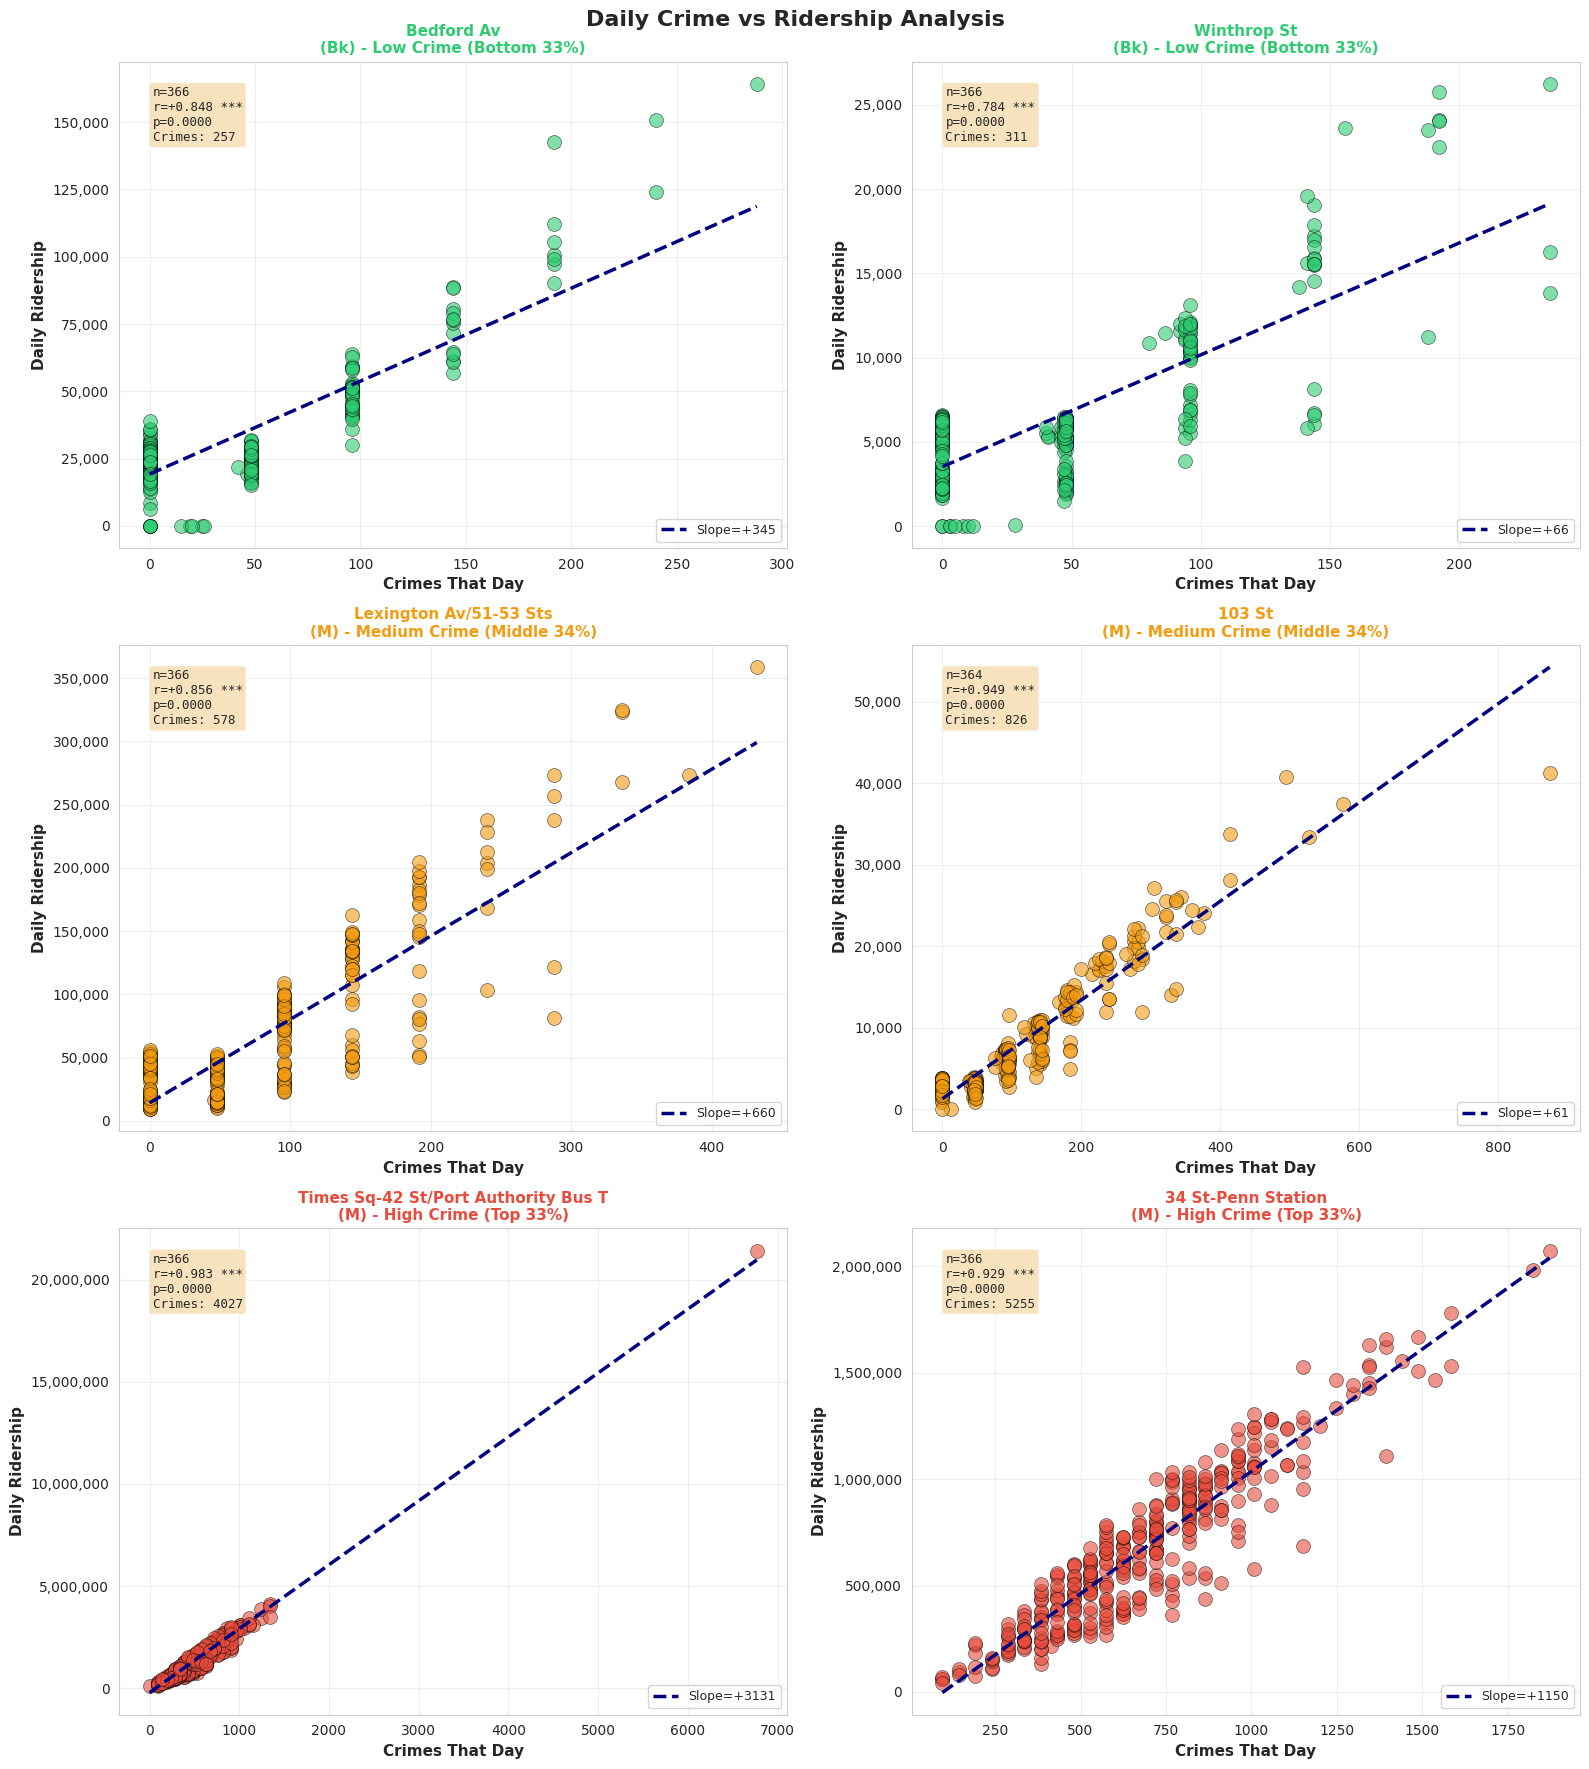


CORRELATION ANALYSIS

Bedford Av (Bk)
  Category: Low Crime (Bottom 33%)
  Correlation: r=+0.8483, p=0.0000
  Interpretation: Sig. positive relationship

Winthrop St (Bk)
  Category: Low Crime (Bottom 33%)
  Correlation: r=+0.7836, p=0.0000
  Interpretation: Sig. positive relationship

Lexington Av/51-53 Sts (M)
  Category: Medium Crime (Middle 34%)
  Correlation: r=+0.8565, p=0.0000
  Interpretation: Sig. positive relationship

103 St (M)
  Category: Medium Crime (Middle 34%)
  Correlation: r=+0.9485, p=0.0000
  Interpretation: Sig. positive relationship

Times Sq-42 St/Port Authority Bus Terminal (M)
  Category: High Crime (Top 33%)
  Correlation: r=+0.9827, p=0.0000
  Interpretation: Sig. positive relationship

34 St-Penn Station (M)
  Category: High Crime (Top 33%)
  Correlation: r=+0.9289, p=0.0000
  Interpretation: Sig. positive relationship


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load
stations_df = pd.read_csv('selected_stations.csv')
daily_df = pd.read_csv('daily_data.csv')
daily_df['ride_date'] = pd.to_datetime(daily_df['ride_date'])

print("="*80)
print("SELECTED STATIONS")
print("="*80)
print(stations_df.to_string(index=False))
print(f"\nTotal daily records: {len(daily_df)}")
print(f"Date range: {daily_df['ride_date'].min()} to {daily_df['ride_date'].max()}")

category_colors = {
    'Low Crime (Bottom 33%)': '#2ecc71',
    'Medium Crime (Middle 34%)': '#f39c12',
    'High Crime (Top 33%)': '#e74c3c'
}

def get_color(category):
    for key in category_colors:
        if key in str(category):
            return category_colors[key]
    return '#95a5a6'


n_stations = len(stations_df)
n_cols = 2
n_rows = (n_stations + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

stations_sorted = stations_df.sort_values(['category_order', 'total_crimes'])

for idx, (_, station) in enumerate(stations_sorted.iterrows()):
    if idx >= len(axes):
        break

    ax = axes[idx]
    station_data = daily_df[daily_df['complex_id'] == station['complex_id']].copy()

    color = get_color(station['crime_category'])
    ax.scatter(station_data['crimes_that_day'],
               station_data['daily_riders'],
               alpha=0.6, s=100, color=color,
               edgecolors='black', linewidth=0.5)

    # Trend
    if len(station_data) > 10:
        z = np.polyfit(station_data['crimes_that_day'],
                       station_data['daily_riders'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(station_data['crimes_that_day'].min(),
                              station_data['crimes_that_day'].max(), 100)
        ax.plot(x_trend, p(x_trend), "navy", linestyle='--',
                linewidth=2.5, label=f'Slope={z[0]:+.0f}')

        corr, p_value = stats.pearsonr(station_data['crimes_that_day'],
                                        station_data['daily_riders'])
        sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        textstr = f'n={len(station_data)}\nr={corr:+.3f} {sig}\np={p_value:.4f}\nCrimes: {int(station["total_crimes"])}'
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85),
                family='monospace')

    ax.set_xlabel('Crimes That Day', fontsize=11, fontweight='bold')
    ax.set_ylabel('Daily Ridership', fontsize=11, fontweight='bold')
    title = f'{station["stop_name"][:35]}\n({station["borough"]}) - {station["crime_category"]}'
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for idx in range(len(stations_sorted), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Daily Crime vs Ridership Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('crime_vs_ridership_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: crime_vs_ridership_analysis.png")
plt.show()

# Summary
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
for _, station in stations_sorted.iterrows():
    station_data = daily_df[daily_df['complex_id'] == station['complex_id']]
    if len(station_data) > 10:
        corr, p_value = stats.pearsonr(station_data['crimes_that_day'],
                                        station_data['daily_riders'])
        print(f"\n{station['stop_name']} ({station['borough']})")
        print(f"  Category: {station['crime_category']}")
        print(f"  Correlation: r={corr:+.4f}, p={p_value:.4f}")
        print(f"  Interpretation: {'Sig. positive' if corr > 0 and p_value < 0.05 else 'Sig. negative' if corr < 0 and p_value < 0.05 else 'No significant'} relationship")


CRIME TYPE CORRELATION ANALYSIS
Stations: 20
Days: 366
Total records: 7320


/tmp/ipython-input-2649818028.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[l.replace('\n', ' ') for l in crime_labels],



✓ Saved: crime_type_analysis.png


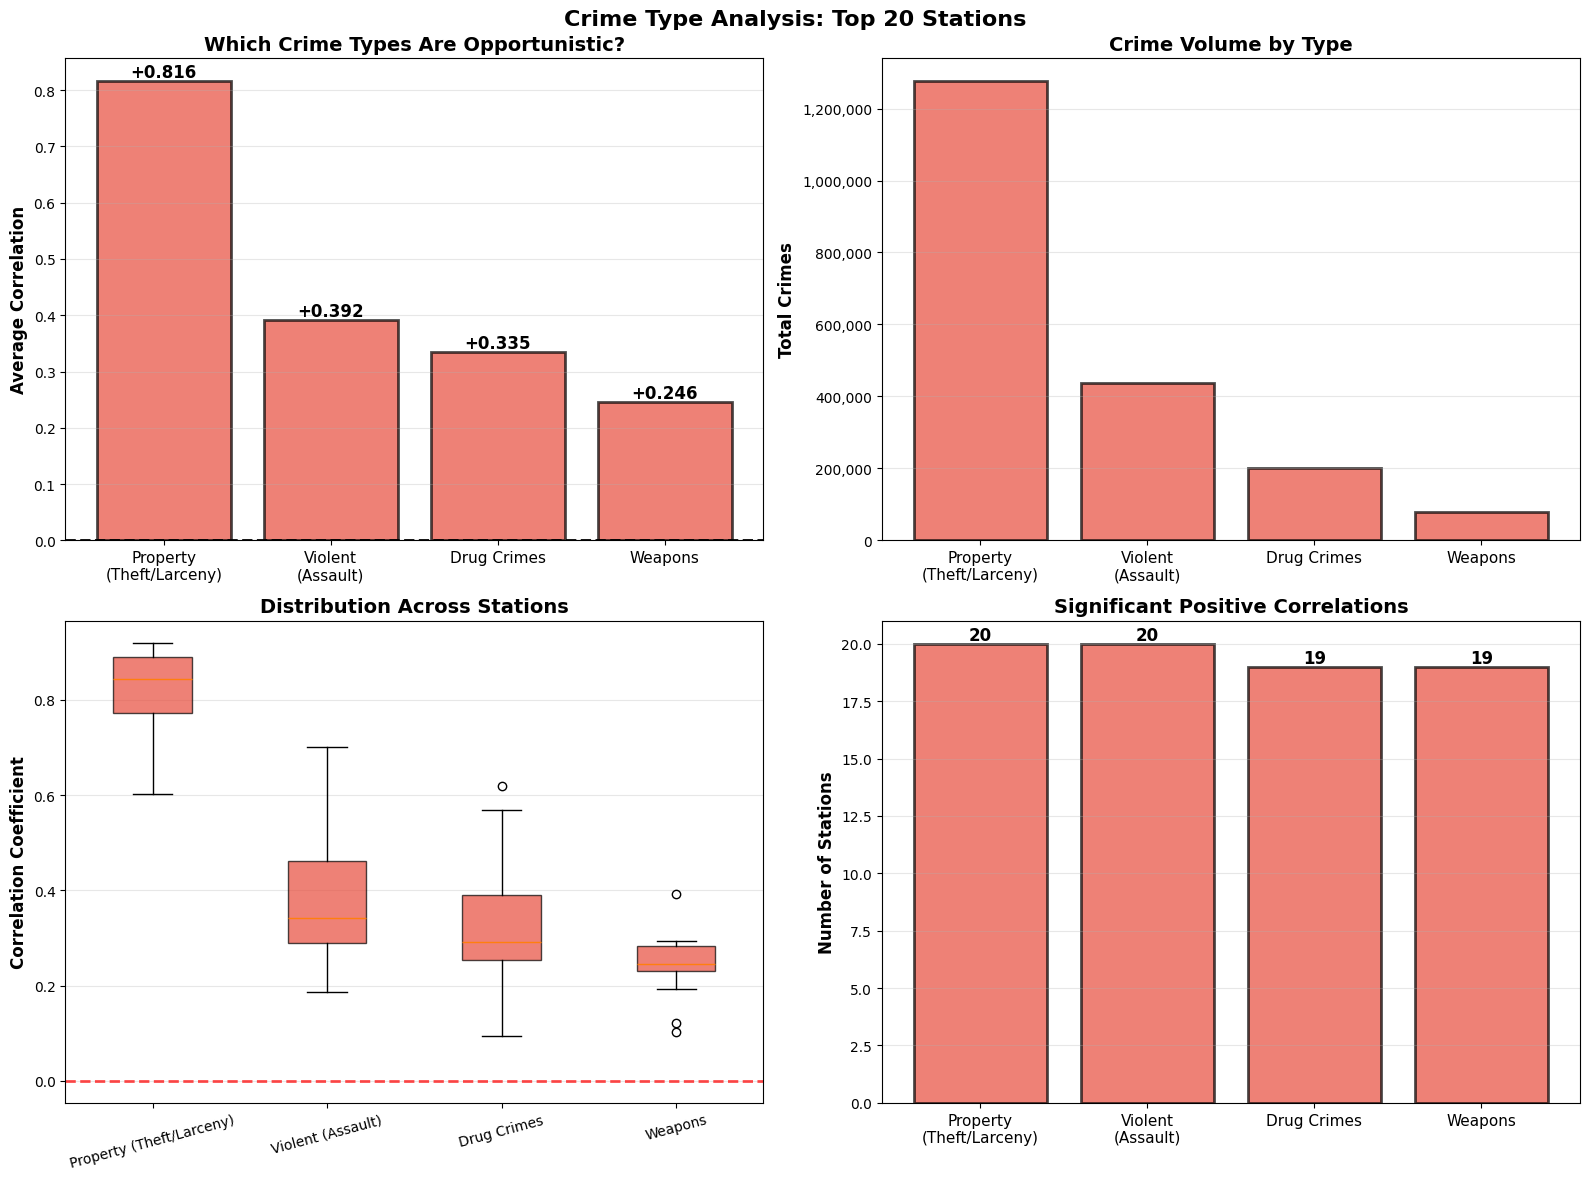


SUMMARY

Property (Theft/Larceny):
  Average correlation: +0.816
  Total crimes: 1,275,791
  Significant at 20/20 stations

Violent (Assault):
  Average correlation: +0.392
  Total crimes: 438,144
  Significant at 20/20 stations

Drug Crimes:
  Average correlation: +0.335
  Total crimes: 200,562
  Significant at 19/20 stations

Weapons:
  Average correlation: +0.246
  Total crimes: 79,747
  Significant at 19/20 stations

→ MOST OPPORTUNISTIC: Property (Theft/Larceny)
  These crimes clearly follow ridership patterns


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load
df = pd.read_csv('crime_types_top20.csv')
df['ride_date'] = pd.to_datetime(df['ride_date'])

print("="*80)
print("CRIME TYPE CORRELATION ANALYSIS")
print("="*80)
print(f"Stations: {df['complex_id'].nunique()}")
print(f"Days: {df['ride_date'].nunique()}")
print(f"Total records: {len(df)}")


crime_types = {
    'property_crimes': 'Property\n(Theft/Larceny)',
    'violent_crimes': 'Violent\n(Assault)',
    'drug_crimes': 'Drug Crimes',
    'weapons_crimes': 'Weapons'
}

# correlations
corr_results = []
for station_id in df['complex_id'].unique():
    station_data = df[df['complex_id'] == station_id]
    station_name = station_data['stop_name'].iloc[0]
    borough = station_data['borough'].iloc[0]

    result = {
        'station_name': station_name,
        'borough': borough
    }

    for crime_col, label in crime_types.items():
        if station_data[crime_col].sum() >= 10:
            corr, p_val = stats.pearsonr(station_data['daily_riders'],
                                          station_data[crime_col])
            result[f'{crime_col}_corr'] = corr
            result[f'{crime_col}_pval'] = p_val
            result[f'{crime_col}_total'] = station_data[crime_col].sum()
        else:
            result[f'{crime_col}_corr'] = np.nan
            result[f'{crime_col}_pval'] = np.nan
            result[f'{crime_col}_total'] = station_data[crime_col].sum()

    corr_results.append(result)

corr_df = pd.DataFrame(corr_results)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average correlations
ax = axes[0, 0]
avg_corrs = [corr_df[f'{ct}_corr'].mean() for ct in crime_types.keys()]
crime_labels = list(crime_types.values())
colors = ['#e74c3c' if c > 0.15 else '#3498db' if c < -0.15 else '#95a5a6'
          for c in avg_corrs]

bars = ax.bar(range(len(crime_labels)), avg_corrs, color=colors,
              alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(crime_labels)))
ax.set_xticklabels(crime_labels, fontsize=11)
ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax.set_ylabel('Average Correlation', fontsize=12, fontweight='bold')
ax.set_title('Which Crime Types Are Opportunistic?', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, avg_corrs):
    ax.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:+.3f}', ha='center',
            va='bottom' if val > 0 else 'top',
            fontsize=12, fontweight='bold')

# Plot 2: Total crimes by type
ax = axes[0, 1]
totals = [corr_df[f'{ct}_total'].sum() for ct in crime_types.keys()]
bars2 = ax.bar(range(len(crime_labels)), totals, color=colors,
               alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(crime_labels)))
ax.set_xticklabels(crime_labels, fontsize=11)
ax.set_ylabel('Total Crimes', fontsize=12, fontweight='bold')
ax.set_title('Crime Volume by Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot 3: Box plots
ax = axes[1, 0]
box_data = [corr_df[f'{ct}_corr'].dropna() for ct in crime_types.keys()]
bp = ax.boxplot(box_data, labels=[l.replace('\n', ' ') for l in crime_labels],
                patch_artist=True, showfliers=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Distribution Across Stations', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Significant positives
ax = axes[1, 1]
sig_counts = []
for ct in crime_types.keys():
    sig = ((corr_df[f'{ct}_corr'] > 0) & (corr_df[f'{ct}_pval'] < 0.05)).sum()
    sig_counts.append(sig)

bars3 = ax.bar(range(len(crime_labels)), sig_counts, color=colors,
               alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(crime_labels)))
ax.set_xticklabels(crime_labels, fontsize=11)
ax.set_ylabel('Number of Stations', fontsize=12, fontweight='bold')
ax.set_title('Significant Positive Correlations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars3, sig_counts):
    ax.text(bar.get_x() + bar.get_width()/2., val,
            f'{int(val)}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

plt.suptitle('Crime Type Analysis: Top 20 Stations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('crime_type_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: crime_type_analysis.png")
plt.show()

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
for idx, (ct, label) in enumerate(crime_types.items()):
    print(f"\n{label.replace(chr(10), ' ')}:")
    print(f"  Average correlation: {avg_corrs[idx]:+.3f}")
    print(f"  Total crimes: {int(totals[idx]):,}")
    print(f"  Significant at {sig_counts[idx]}/{len(corr_df)} stations")

max_idx = avg_corrs.index(max(avg_corrs))
print(f"\n→ MOST OPPORTUNISTIC: {list(crime_types.values())[max_idx].replace(chr(10), ' ')}")
print(f"  These crimes clearly follow ridership patterns")
